
PHASE 3 — PROPHET + HOLIDAYS
Donation Forecasting Research | Tavishi Jain
Dataset: Superstore Sales (monthly)

SETUP & RE-LOAD 

In [1]:




import zipfile, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi'   : 150,
    'savefig.dpi'  : 300,
    'font.size'    : 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})
os.makedirs('figures', exist_ok=True)
os.makedirs('data',    exist_ok=True)

with zipfile.ZipFile(r'C:/Users/tavis/Downloads/archive (1).zip', 'r') as z:
    z.extractall(r'C:/Users/tavis/Downloads/archive (1)')

df = pd.read_csv(
    r'C:/Users/tavis/Downloads/archive (1)/Sample - Superstore.csv',
    encoding='ISO-8859-1'
)
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly = df.resample('ME', on='Order Date')['Sales'].sum()


split = int(len(monthly) * 0.8)
train = monthly[:split]
test  = monthly[split:]

print("Data loaded successfully.")
print(f"  Total months : {len(monthly)}")
print(f"  Train months : {len(train)}  ({train.index[0].date()} → {train.index[-1].date()})")
print(f"  Test  months : {len(test)}   ({test.index[0].date()} → {test.index[-1].date()})")

def evaluate(actual, predicted):
    actual    = np.array(actual,    dtype=float)
    predicted = np.array(predicted, dtype=float)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mask = actual != 0                        # avoid divide-by-zero
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    return {'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'MAPE': round(mape, 2)}


results = {
    'ARIMA': {'RMSE': 25445.61, 'MAE': 19981.86, 'MAPE': 26.46},
    'ETS'  : {'RMSE': 12396.26, 'MAE': 11175.29, 'MAPE': 18.52},
}


print("\nPhase 2 results carried forward:")
print(pd.DataFrame(results).T.to_string())
print("\nSetup complete. Proceed to Cell 2.")




Data loaded successfully.
  Total months : 48
  Train months : 38  (2014-01-31 → 2017-02-28)
  Test  months : 10   (2017-03-31 → 2017-12-31)

Phase 2 results carried forward:
           RMSE       MAE   MAPE
ARIMA  25445.61  19981.86  26.46
ETS    12396.26  11175.29  18.52

Setup complete. Proceed to Cell 2.


PROPHET DATA PREP + BASIC FIT

In [2]:


 
from prophet import Prophet



df_prophet = (
    monthly
    .reset_index()
    .rename(columns={'Order Date': 'ds', 'Sales': 'y'})
)
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

train_p = df_prophet.iloc[:split].copy()
test_p  = df_prophet.iloc[split:].copy()

print("Prophet dataframe ready.")
print(f"  Train rows : {len(train_p)}")
print(f"  Test  rows : {len(test_p)}")
print(train_p.tail(3))


m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)
m.fit(train_p)
print("\nBaseline Prophet fitted.")

future     = m.make_future_dataframe(periods=len(test_p), freq='ME')
forecast_p = m.predict(future)


test_forecast_p = (
    forecast_p[forecast_p['ds'].isin(test_p['ds'])]['yhat'].values
)

print("Forecast generated.")
print(forecast_p[['ds','yhat','yhat_lower','yhat_upper']].tail(len(test_p)).to_string())




Importing plotly failed. Interactive plots will not work.


Prophet dataframe ready.
  Train rows : 38
  Test  rows : 10
           ds           y
35 2016-12-31  96999.0430
36 2017-01-31  43971.3740
37 2017-02-28  20301.1334


11:45:13 - cmdstanpy - INFO - Chain [1] start processing
11:45:13 - cmdstanpy - INFO - Chain [1] done processing



Baseline Prophet fitted.
Forecast generated.
           ds          yhat    yhat_lower     yhat_upper
38 2017-03-31  59393.482602  52017.011879   67102.934754
39 2017-04-30  44182.460947  37690.360277   51598.853807
40 2017-05-31  53137.890885  46368.328721   60798.540462
41 2017-06-30  46257.408376  38925.516392   53383.172382
42 2017-07-31  46231.535851  38749.922100   53772.677151
43 2017-08-31  40983.139302  33265.999799   47917.454368
44 2017-09-30  84371.833031  76910.548342   91702.220934
45 2017-10-31  56869.079490  49436.616676   64445.379839
46 2017-11-30  87505.136861  79611.763619   94697.785864
47 2017-12-31  94460.391184  86572.710064  101567.417013


PROPHET FIGURES + EVALUATION

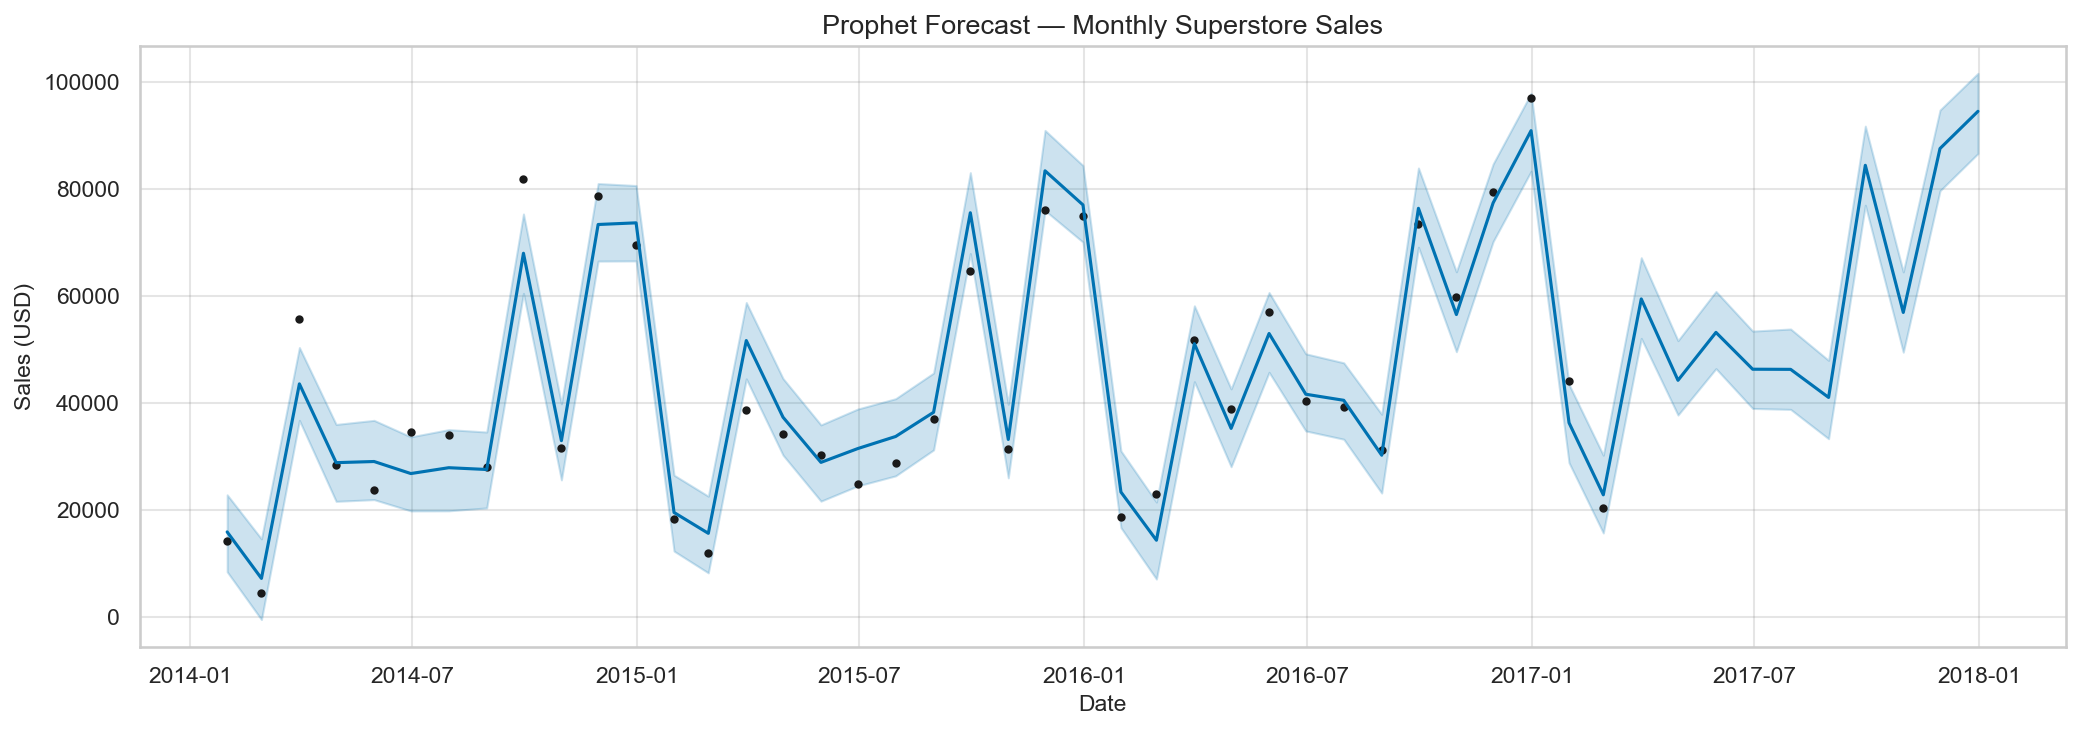

fig10 saved → figures/fig10_prophet_forecast.png


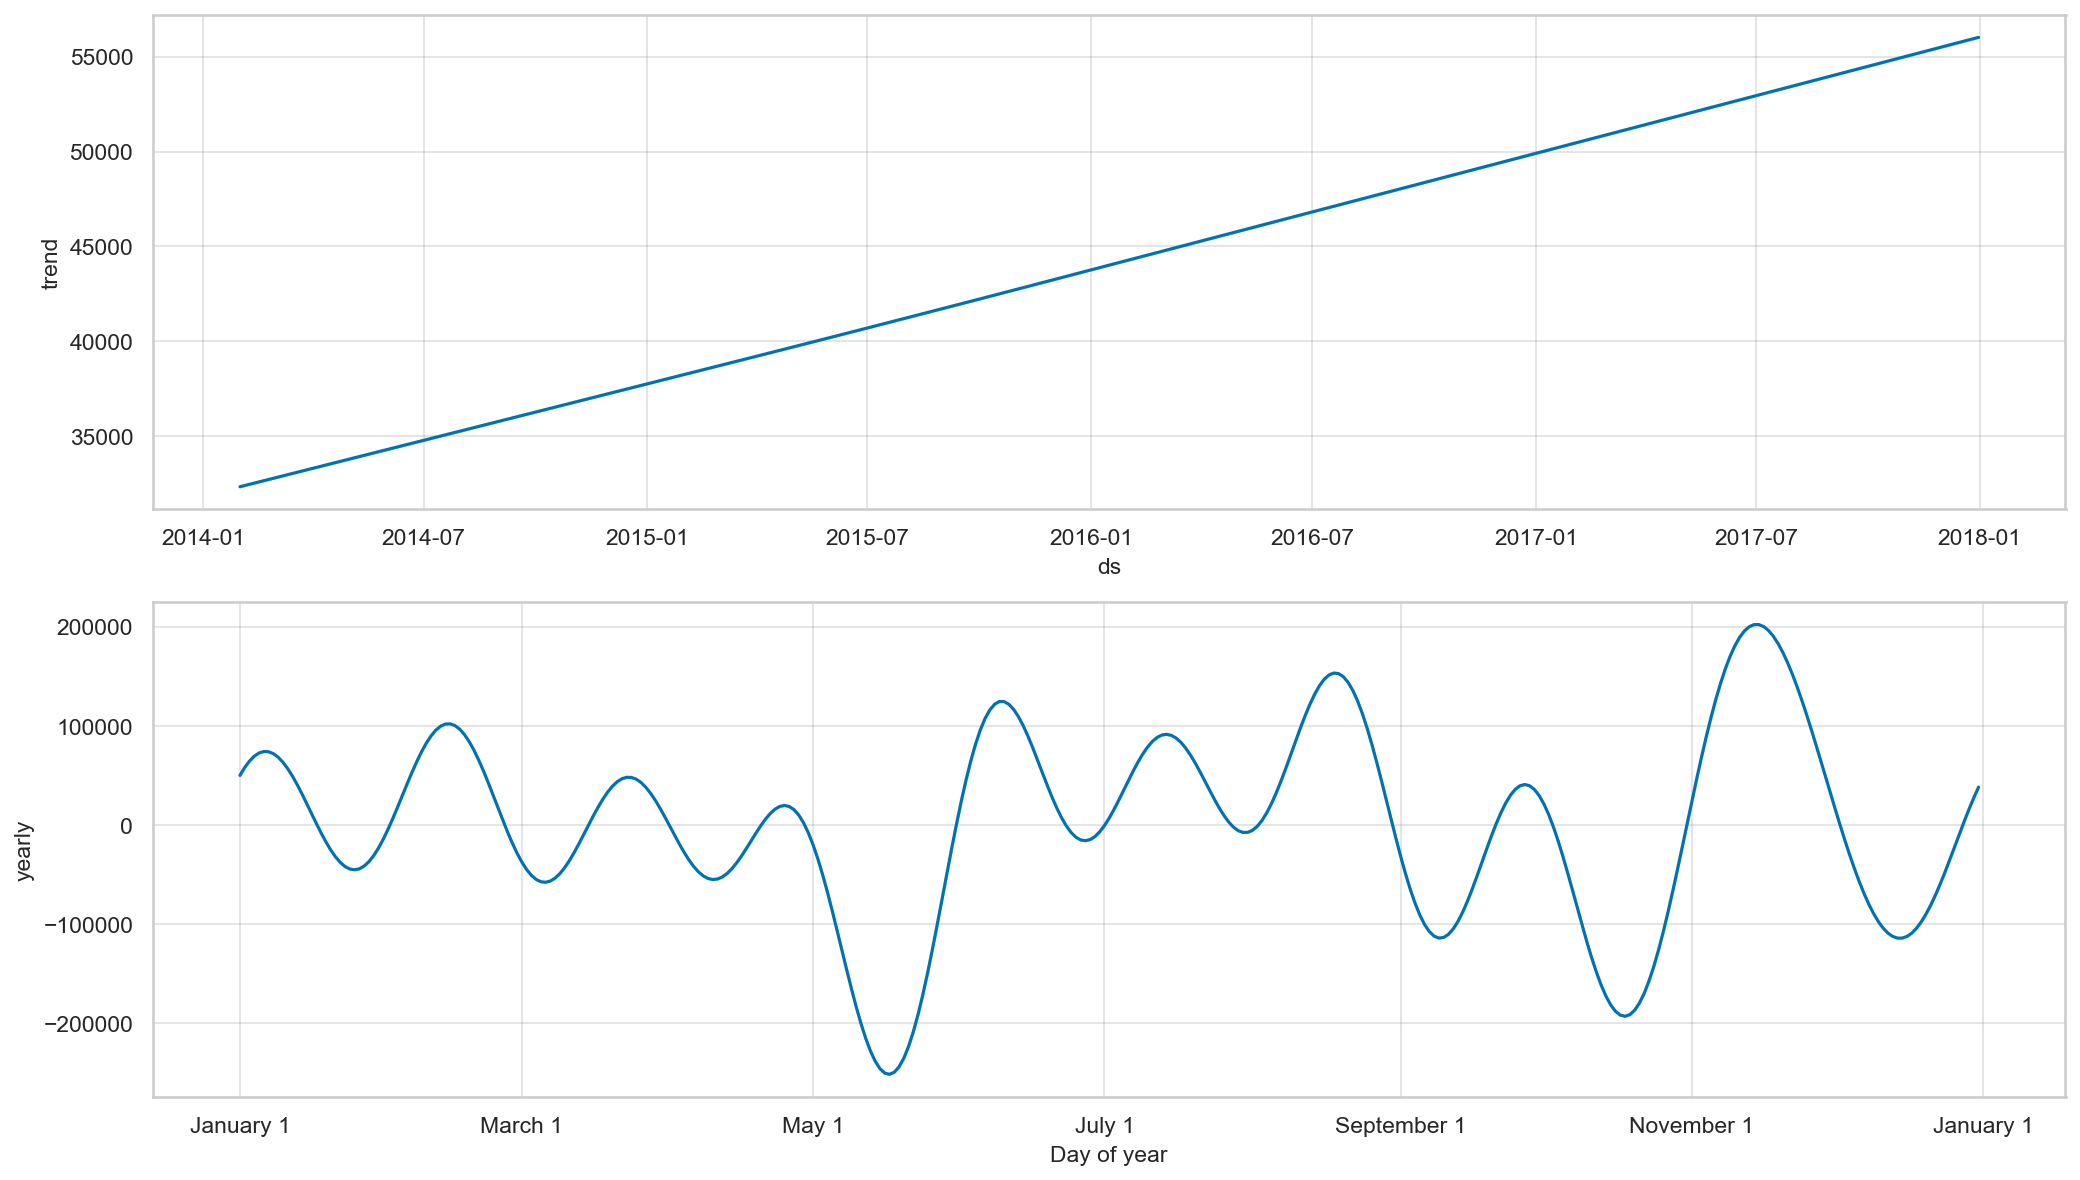

fig11 saved → figures/fig11_prophet_components.png

── Baseline Prophet Metrics ──
  RMSE: 14811.52
  MAE: 11286.44
  MAPE: 16.15

── Results so far ──
             RMSE       MAE   MAPE
ARIMA    25445.61  19981.86  26.46
ETS      12396.26  11175.29  18.52
Prophet  14811.52  11286.44  16.15


In [3]:





fig10 = m.plot(forecast_p)
fig10.set_size_inches(14, 5)
fig10.axes[0].set_title('Prophet Forecast — Monthly Superstore Sales', fontsize=13)
fig10.axes[0].set_xlabel('Date')
fig10.axes[0].set_ylabel('Sales (USD)')
plt.tight_layout()
plt.savefig('figures/fig10_prophet_forecast.png', dpi=300, bbox_inches='tight')
plt.show()
print("fig10 saved → figures/fig10_prophet_forecast.png")

fig11 = m.plot_components(forecast_p)
fig11.set_size_inches(14, 8)
plt.tight_layout()
plt.savefig('figures/fig11_prophet_components.png', dpi=300, bbox_inches='tight')
plt.show()
print("fig11 saved → figures/fig11_prophet_components.png")


prophet_metrics = evaluate(test_p['y'].values, test_forecast_p)
results['Prophet'] = prophet_metrics

print("\n── Baseline Prophet Metrics ──")
for k, v in prophet_metrics.items():
    print(f"  {k}: {v}")


print("\n── Results so far ──")
print(pd.DataFrame(results).T.to_string())




HOLIDAY EXPERIMENT


In [4]:







m_holidays = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    holidays_prior_scale=10,   
)
m_holidays.add_country_holidays(country_name='IN')
m_holidays.fit(train_p)
print("Prophet + Indian Holidays fitted.")

future_h   = m_holidays.make_future_dataframe(periods=len(test_p), freq='ME')
forecast_h = m_holidays.predict(future_h)

test_forecast_h = (
    forecast_h[forecast_h['ds'].isin(test_p['ds'])]['yhat'].values
)


holiday_metrics = evaluate(test_p['y'].values, test_forecast_h)
results['Prophet+Holidays'] = holiday_metrics

print("\n── Prophet + Holidays Metrics ──")
for k, v in holiday_metrics.items():
    print(f"  {k}: {v}")

mape_base     = results['Prophet']['MAPE']
mape_holidays = results['Prophet+Holidays']['MAPE']
improvement   = round(mape_base - mape_holidays, 2)

print(f"\n══ RQ2 ANSWER ══════════════════════════════")
print(f"  Prophet MAPE (no holidays)   : {mape_base}%")
print(f"  Prophet MAPE (with holidays) : {mape_holidays}%")
print(f"  MAPE change                  : {improvement:+.2f} percentage points")
if improvement > 0:
    print("  → Holidays IMPROVED forecast accuracy.")
elif improvement == 0:
    print("  → Holidays made NO difference.")
else:
    print("  → Holidays HURT accuracy (note this honestly in the paper).")
print("════════════════════════════════════════════")




11:45:16 - cmdstanpy - INFO - Chain [1] start processing
11:45:16 - cmdstanpy - INFO - Chain [1] done processing


Prophet + Indian Holidays fitted.

── Prophet + Holidays Metrics ──
  RMSE: 14811.52
  MAE: 11286.44
  MAPE: 16.15

══ RQ2 ANSWER ══════════════════════════════
  Prophet MAPE (no holidays)   : 16.15%
  Prophet MAPE (with holidays) : 16.15%
  MAPE change                  : +0.00 percentage points
  → Holidays made NO difference.
════════════════════════════════════════════


IDENTIFY TOP IMPACTFUL HOLIDAYS

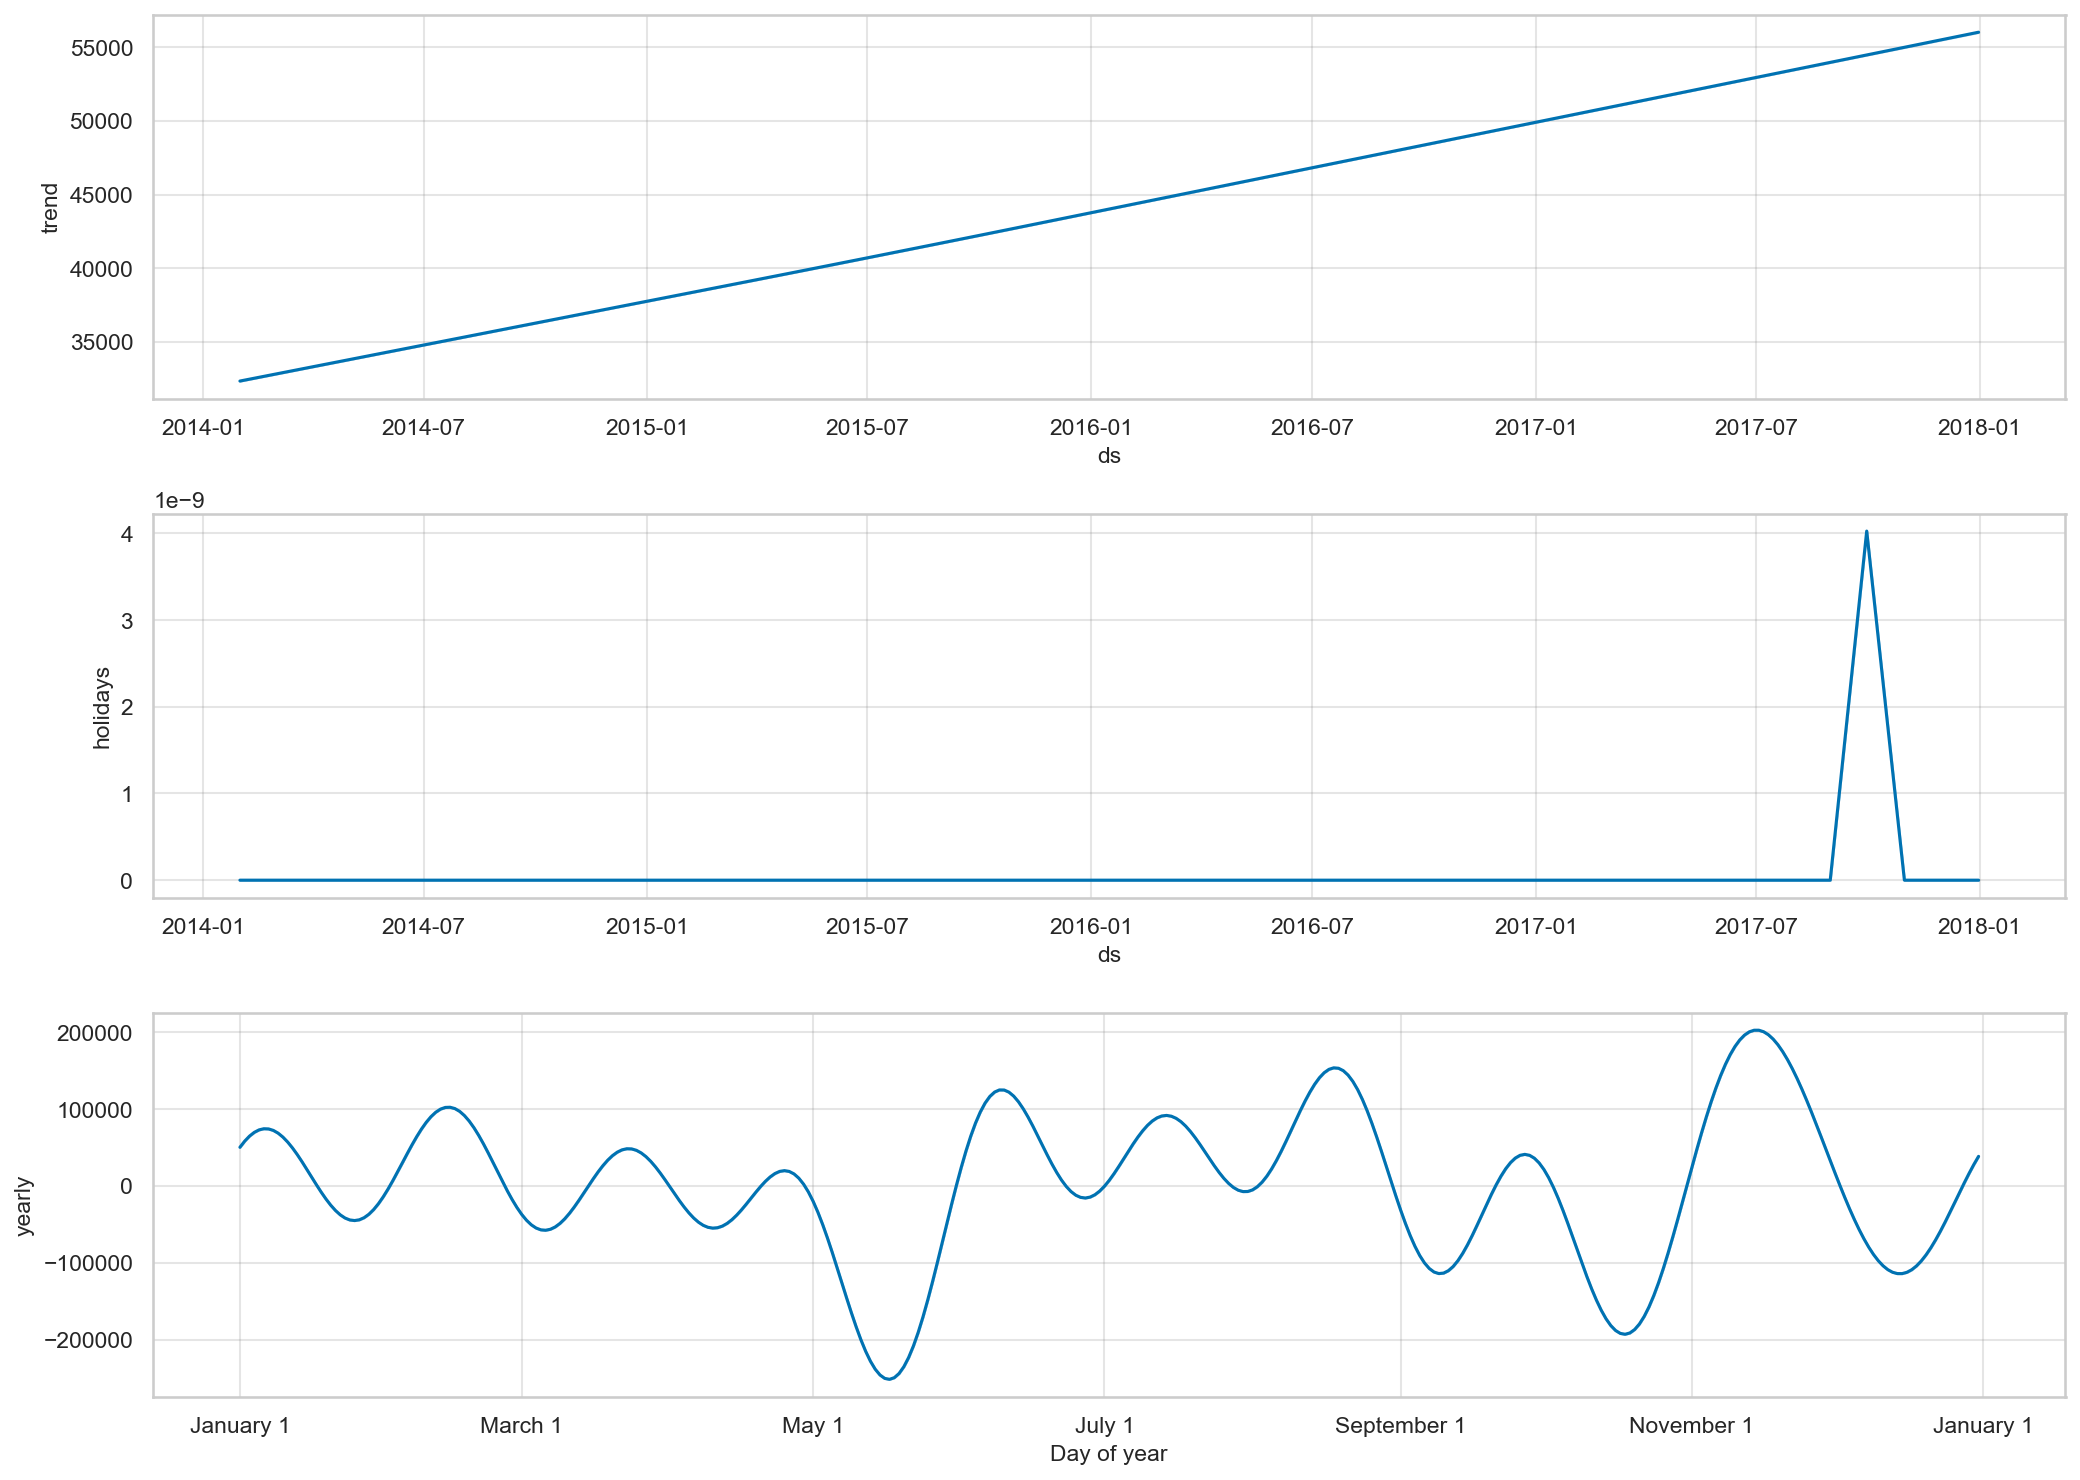

fig11b saved → figures/fig11b_holiday_components.png

── Top 10 Holiday Effects (mean absolute uplift in USD) ──
Dussehra              8.389434e-11
Ashura                0.000000e+00
Christmas             0.000000e+00
Buddha Purnima        0.000000e+00
Diwali                0.000000e+00
Eid al-Adha           0.000000e+00
Eid al-Fitr           0.000000e+00
Gandhi Jayanti        0.000000e+00
Good Friday           0.000000e+00
Guru Nanak Jayanti    0.000000e+00

Top 3 most impactful: ['Dussehra', 'Ashura', 'Christmas']


In [5]:






fig_hc = m_holidays.plot_components(forecast_h)
fig_hc.set_size_inches(14, 10)
plt.tight_layout()
plt.savefig('figures/fig11b_holiday_components.png', dpi=300, bbox_inches='tight')
plt.show()
print("fig11b saved → figures/fig11b_holiday_components.png")

skip_cols = {
    'ds','trend','yhat','yhat_lower','yhat_upper',
    'trend_lower','trend_upper',
    'additive_terms','additive_terms_lower','additive_terms_upper',
    'multiplicative_terms','multiplicative_terms_lower','multiplicative_terms_upper',
    'yearly','yearly_lower','yearly_upper',
    'holidays','holidays_lower','holidays_upper',
}
holiday_cols = [
    c for c in forecast_h.columns
    if c not in skip_cols and 'lower' not in c and 'upper' not in c
]

if holiday_cols:
    holiday_effects = (
        forecast_h[holiday_cols]
        .abs()
        .mean()
        .sort_values(ascending=False)
    )
    print("\n── Top 10 Holiday Effects (mean absolute uplift in USD) ──")
    print(holiday_effects.head(10).to_string())
    top3 = list(holiday_effects.head(3).index)
    print(f"\nTop 3 most impactful: {top3}")
else:
    print("Note: Holiday effects are aggregated. See the components plot (fig11b) for the pattern.")

    


CROSS-VALIDATION

In [6]:


from prophet.diagnostics import cross_validation, performance_metrics

print("Running cross-validation (takes ~1-3 minutes)...")


df_cv = cross_validation(
    m_holidays,
    initial='730 days',    
    period='90 days',     
    horizon='180 days',    
    parallel='processes'
)

df_p_metrics = performance_metrics(df_cv)

print("\n── Cross-Validation Results (by horizon) ──")
print(df_p_metrics[['horizon','rmse','mae','mape']].to_string(index=False))

cv_mape_mean = round(df_p_metrics['mape'].mean() * 100, 2)
cv_mape_max  = round(df_p_metrics['mape'].max()  * 100, 2)
print(f"\nMean cross-validated MAPE : {cv_mape_mean}%")
print(f"Max  cross-validated MAPE : {cv_mape_max}%  (worst horizon)")



Running cross-validation (takes ~1-3 minutes)...

── Cross-Validation Results (by horizon) ──
 horizon         rmse          mae     mape
 26 days 28184.003836 28184.003836 0.544978
 27 days 15736.920629 15736.920629 0.390063
 29 days 24768.931348 24768.931348 0.337405
 56 days 30718.441823 30718.441823 0.792733
 58 days 12715.913481 12715.913481 0.323874
 60 days 29027.991326 29027.991326 0.486331
 87 days 55433.662865 55433.662865 0.972730
 89 days 30151.689327 30151.689327 0.969029
 90 days 13346.713507 13346.713507 0.168069
117 days  5295.124586  5295.124586 0.131248
119 days 41533.031352 41533.031352 0.565768
121 days 27518.832572 27518.832572 0.283702
148 days  1785.894437  1785.894437 0.045487
150 days 23407.397636 23407.397636 0.392164
152 days 16758.739093 16758.739093 0.381128
179 days 28470.216010 28470.216010 0.914989
180 days  6127.159417  5454.268867 0.117498

Mean cross-validated MAPE : 45.98%
Max  cross-validated MAPE : 97.27%  (worst horizon)


CUSTOM SEASONALITY VARIANT

In [7]:






m_custom = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    holidays_prior_scale=10,
)
m_custom.add_country_holidays(country_name='IN')
m_custom.add_seasonality(
    name='quarterly',
    period=91.25,       # ~3 months — meaningful for retail/sales data
    fourier_order=5
)
m_custom.fit(train_p)

future_c   = m_custom.make_future_dataframe(periods=len(test_p), freq='ME')
forecast_c = m_custom.predict(future_c)

test_forecast_c = (
    forecast_c[forecast_c['ds'].isin(test_p['ds'])]['yhat'].values
)
custom_metrics = evaluate(test_p['y'].values, test_forecast_c)
results['Prophet+Holidays+Quarterly'] = custom_metrics

mape_custom   = custom_metrics['MAPE']
mape_holidays = results['Prophet+Holidays']['MAPE']

print("── Prophet + Holidays + Quarterly Seasonality ──")
for k, v in custom_metrics.items():
    print(f"  {k}: {v}")

if mape_custom < mape_holidays:
    print(f"\n  → Quarterly seasonality HELPS  ({mape_custom}% vs {mape_holidays}%)")
else:
    print(f"\n  → Quarterly seasonality does NOT help  ({mape_custom}% vs {mape_holidays}%)")
    


11:45:20 - cmdstanpy - INFO - Chain [1] start processing
11:45:20 - cmdstanpy - INFO - Chain [1] done processing


── Prophet + Holidays + Quarterly Seasonality ──
  RMSE: 20304.78
  MAE: 17266.1
  MAPE: 25.8

  → Quarterly seasonality does NOT help  (25.8% vs 16.15%)


3-MODEL COMPARISON FIGURE

Phase 2 models re-fitted for comparison chart.


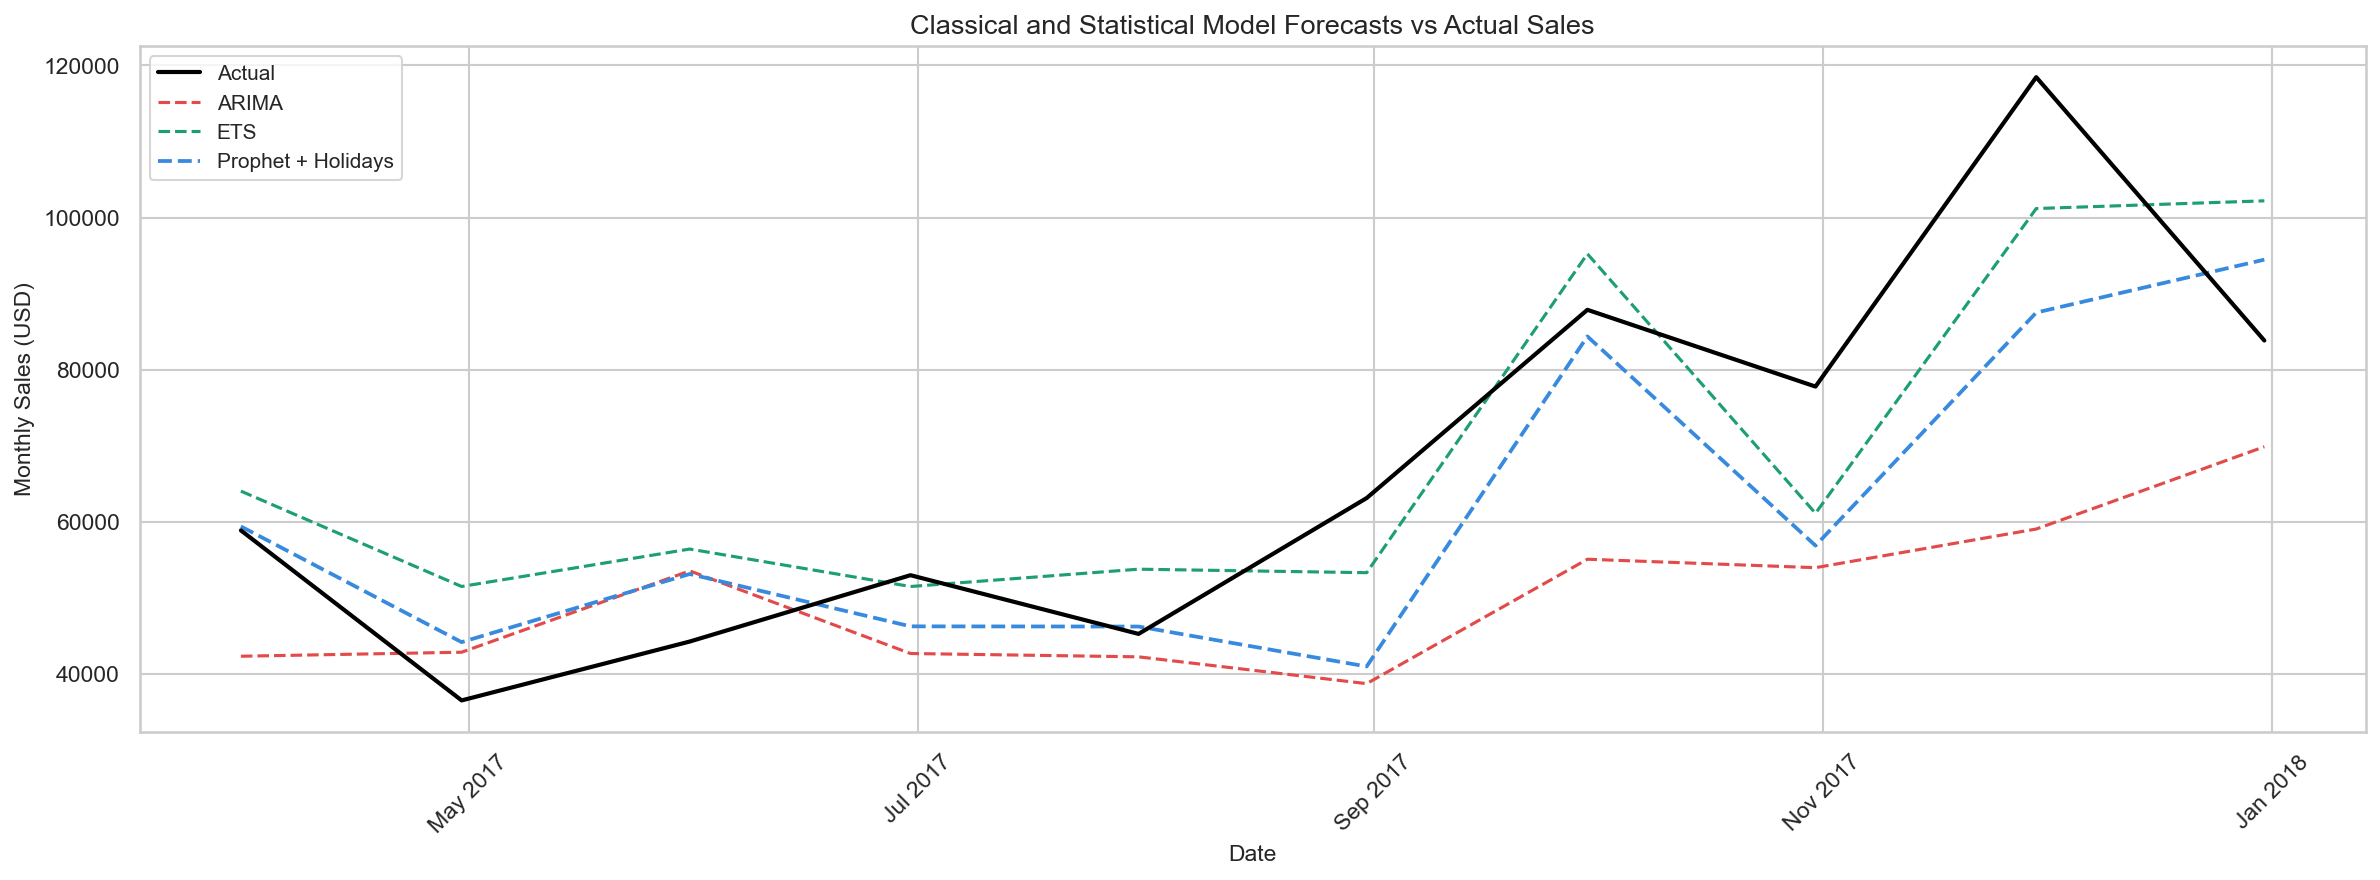

fig12 saved → figures/fig12_three_model_compare.png


In [8]:



from pmdarima import auto_arima
model_arima_refit = auto_arima(
    train,
    seasonal=True, m=12,
    stepwise=True,
    suppress_warnings=True,
    information_criterion='aic',
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    D=0,
    error_action='ignore'
)
forecast_arima_refit = model_arima_refit.predict(n_periods=len(test))

# Quick ETS re-fit
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model_ets_refit    = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
forecast_ets_refit = model_ets_refit.forecast(len(test))

print("Phase 2 models re-fitted for comparison chart.")

fig12, ax = plt.subplots(figsize=(16, 6))

ax.plot(test.index, test.values,
        color='black', linewidth=2, label='Actual', zorder=5)
ax.plot(test.index, forecast_arima_refit,
        color='#E24B4A', linewidth=1.5, linestyle='--', label='ARIMA')
ax.plot(test.index, forecast_ets_refit.values,
        color='#1D9E75', linewidth=1.5, linestyle='--', label='ETS')
ax.plot(test.index, test_forecast_h,
        color='#378ADD', linewidth=1.8, linestyle='--', label='Prophet + Holidays')

ax.set_title('Classical and Statistical Model Forecasts vs Actual Sales', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Sales (USD)')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/fig12_three_model_compare.png', dpi=300, bbox_inches='tight')
plt.show()
print("fig12 saved → figures/fig12_three_model_compare.png")



FINAL RESULTS TABLE 

In [ ]:






results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'

print("\n══════════════════════════════════════════════════════")
print("         PHASE 3 COMPLETE — FULL RESULTS TABLE        ")
print("══════════════════════════════════════════════════════")
print(results_df.to_string())
print("══════════════════════════════════════════════════════")

best_model = results_df['MAPE'].astype(float).idxmin()
best_mape  = results_df.loc[best_model, 'MAPE']
print(f"\nBest model so far : {best_model}  (MAPE = {best_mape}%)")

p_mape   = results['Prophet']['MAPE']
ph_mape  = results['Prophet+Holidays']['MAPE']
imp      = round(p_mape - ph_mape, 2)
arima_m  = results['ARIMA']['MAPE']
ets_m    = results['ETS']['MAPE']




══════════════════════════════════════════════════════
         PHASE 3 COMPLETE — FULL RESULTS TABLE        
══════════════════════════════════════════════════════
                                RMSE       MAE   MAPE
Model                                                
ARIMA                       25445.61  19981.86  26.46
ETS                         12396.26  11175.29  18.52
Prophet                     14811.52  11286.44  16.15
Prophet+Holidays            14811.52  11286.44  16.15
Prophet+Holidays+Quarterly  20304.78  17266.10  25.80
══════════════════════════════════════════════════════

Best model so far : Prophet  (MAPE = 16.15%)

══ COPY INTO OVERLEAF ══════════════════════════════════
  ARIMA MAPE                        : 26.46%
  ETS MAPE                          : 18.52%
  Prophet (baseline) MAPE           : 16.15%
  Prophet + Holidays MAPE           : 16.15%
  MAPE improvement from holidays    : +0.00 pp
  Quarterly seasonality variant MAPE: 25.8%
  Cross-validated MAPE (me